# Assignment #4 - Training ML Models to Predict Passenger Survival on the Titanic Dataset

**Ja'farbek Yusupov | 240057 | SAR1**

Task: training and comparing different ML classification algorithms on the public Titanic dataset

Dataset: Titanic - Machine Learning from Disaster, https://www.kaggle.com/competitions/titanic/data

dataset contains:
- `train.csv` - training set with survival labels (used for all training and cross-validation)
- *test.csv - not used for evaluation per task requirements*

## Imports

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold,
    cross_validate,
    cross_val_score, 
    GridSearchCV
)
from sklearn.metrics import (
    accuracy_score,
    f1_score, 
    precision_score, 
    recall_score,
    classification_report,
    confusion_matrix,
    make_scorer
)

# classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC

sns.set_style('whitegrid')
RANDOM_STATE = 42
print('lib import done')

lib import done


# Step 1 - Performance Metric Selection

| Metric | Formula | When to use |
|--------|---------|------------|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | Balanced classes |
| **Precision** | TP/(TP+FP) | Minimise false positives |
| **Recall** | TP/(TP+FN) | Minimise false negatives |
| **F1 Score** | 2·P·R/(P+R) | Imbalanced classes |
| **AUC-ROC** | Area under ROC curve | Overall ranking quality |

### Chosen metrics: **accuracy** and **F1 Score**

**explanation:**
the titanic training set is imbalanced - *549 deaths (61.6%)* vs *342 survivors (38.4%)*. A trivial model that always predicts "did not survive" would already reach 61.6% accuracy without learning anything. F1 score balances precision and recall, penalising models that ignore the minority class. Both mentioned metrics give us complete picture - accuracy is comparable to Kaggle leaderboard scores, while F1 guards helps to prevent misleading accuracy results caused by class imbalance.

# Step 2 - Data Preparation & Preprocessing

## 2.1 load the dataset

In [59]:
df = pd.read_csv('../data/train.csv')
print(f'dataset shape: {df.shape}')
df.head()

dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2.2 descriptive statistics

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [61]:
print('survival distribution:')
print(df['Survived'].value_counts().rename({0: 'did not survive', 1: 'survived'}))
print(f'\nSurvival rate: {df["Survived"].mean()*100:.1f} %')

survival distribution:
Survived
did not survive    549
survived           342
Name: count, dtype: int64

Survival rate: 38.4 %


In [62]:
# check for missing vals
missing = df.isnull().sum()
print('missing values:')
print(missing[missing > 0].to_string())

missing values:
Age         177
Cabin       687
Embarked      2


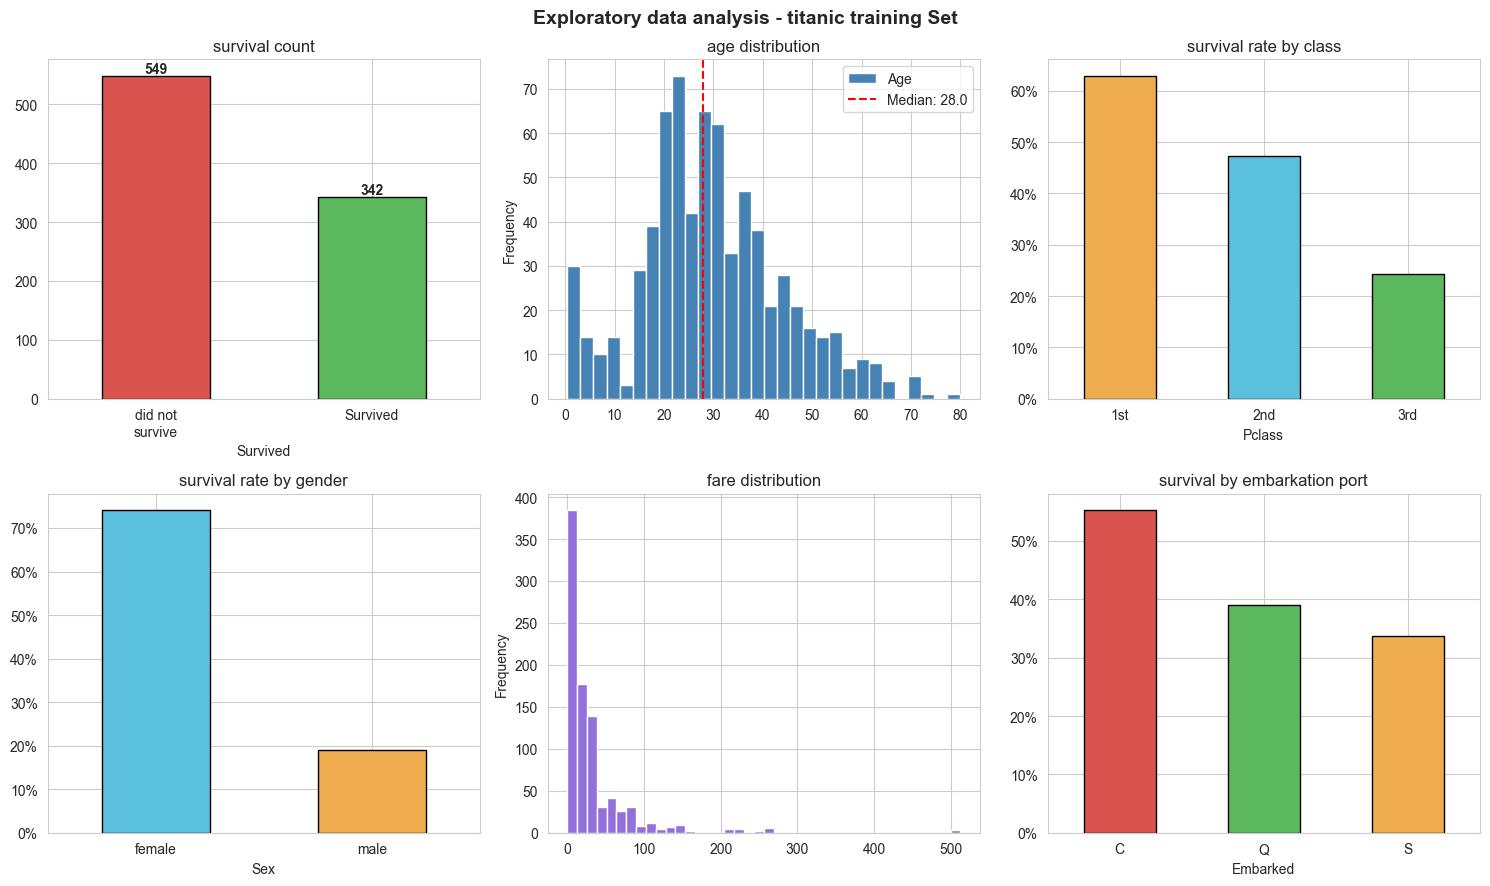

In [64]:
# key data patterns visualized
fig, axes = plt.subplots(2, 3, figsize=(15,9))
fig.suptitle('Exploratory data analysis - titanic training Set', fontsize=14, fontweight='bold')

ax = axes[0, 0]
df['Survived'].value_counts().rename({0:'did not\nsurvive', 1:'Survived'}).plot(
    kind='bar', 
    ax=ax, 
    color=['#d9534f','#5cb85c'], 
    edgecolor='black'
)
ax.set_title('survival count'); ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())), 
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', 
        va='bottom', 
        fontweight='bold'
    )

ax = axes[0, 1]
df['Age'].dropna().plot(kind='hist', bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(df['Age'].median(), color='red', linestyle='--', label=f'Median: {df["Age"].median():.1f}')
ax.set_title('age distribution'); ax.legend()

ax = axes[0, 2]
df.groupby('Pclass')['Survived'].mean().mul(100).plot(kind='bar', ax=ax,
    color=['#f0ad4e','#5bc0de','#5cb85c'], edgecolor='black')
ax.set_title('survival rate by class'); ax.set_xticklabels(['1st','2nd','3rd'], rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax = axes[1, 0]
df.groupby('Sex')['Survived'].mean().mul(100).plot(
    kind='bar', 
    ax=ax,
    color=['#5bc0de','#f0ad4e'], 
    edgecolor='black'
)
ax.set_title('survival rate by gender'); ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax = axes[1, 1]
df['Fare'].plot(kind='hist', bins=40, ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('fare distribution')

ax = axes[1, 2]
df.groupby('Embarked')['Survived'].mean().mul(100).plot(
    kind='bar',
    ax=ax,
    color=['#d9534f','#5cb85c','#f0ad4e'],
    edgecolor='black'
)
ax.set_title('survival by embarkation port')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

## 2.3 data cleaning (handling `NaN` values)

**handling strategies for each missing value category:**
- **age** (19.9% missing) -> impute with *median* inside the sklearn Pipeline (no leakage)
- **embarked** (0.2% missing, 2 rows) -> impute with *mode* (most frequent='S')
- **cabin** (77.1% missing) -> too sparse to impute; replaced with binary flag `hasCabin`
- **name**, **ticket**, **passengerId** -> dropped (not significant - are identifiers, not predictive features)

## 2.4 feature engineering

In [65]:
def preprocess_raw(df_in):
    df_out = df_in.copy()

    # family features (travelling alone - known survival factor)
    df_out['FamilySize'] = df_out['SibSp'] + df_out['Parch'] + 1
    df_out['IsAlone'] = (df_out['FamilySize'] == 1).astype(int)

    # correlates with passenger class and deck access
    df_out['HasCabin'] = df_out['Cabin'].notna().astype(int)

    # social clues in name: title encodes gender, age, status
    df_out['Title'] = df_out['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    rare_titles = {'Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'}
    df_out['Title'] = df_out['Title'].replace(list(rare_titles), 'Rare')
    df_out['Title'] = df_out['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # drop identifier columns
    df_out = df_out.drop(columns=['PassengerId','Name','Ticket','Cabin'], errors='ignore')
    return df_out

df_clean = preprocess_raw(df)
print('shape after feature engineering:', df_clean.shape)
print('\ntitle distribution:')
print(df_clean['Title'].value_counts())

shape after feature engineering: (891, 12)

title distribution:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


## 2.5 encoding - OneHotEncoder for categorical features

In [66]:
NUMERICAL_FEATURES   = ['Pclass','Age','SibSp','Parch','Fare','FamilySize','IsAlone','HasCabin']
CATEGORICAL_FEATURES = ['Sex','Embarked','Title']
TARGET = 'Survived'

X_raw = df_clean[NUMERICAL_FEATURES + CATEGORICAL_FEATURES]
y = df_clean[TARGET]

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline,   NUMERICAL_FEATURES),
    ('cat', categorical_pipeline, CATEGORICAL_FEATURES)
])

# fit and transform to inspect the final feature set
X = preprocessor.fit_transform(X_raw)
ohe_names = (preprocessor
                .named_transformers_['cat']
                .named_steps['onehot']
                .get_feature_names_out(CATEGORICAL_FEATURES)
            )
feature_names = NUMERICAL_FEATURES + list(ohe_names)

print(f'original features: {X_raw.shape[1]}')
print(f'after encoding: {X.shape[1]}  features')
print(f'all feature names: {feature_names}')

original features: 11
after encoding: 18  features
all feature names: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


## 2.6 train/validation split

for reporting per-sample metrics (classification report, confusion matrix) we split off a held-out set. 

**only `train.csv` is used for cross-validation.**

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f'training set: {X_train.shape[0]} samples')
print(f'validation set: {X_test.shape[0]} samples')
print(f'survival rate (train): {y_train.mean()*100:.1f} %')
print(f'survival rate (test): {y_test.mean()*100:.1f} %')

training set: 712 samples
validation set: 179 samples
survival rate (train): 38.3 %
survival rate (test): 38.5 %


# Step 3 - train classification algorithms

#### cross-validation setup:
- `cross_validate` with `Stratified 5-Fold` CV (preserves class ratio in every fold)
- metrics: accuracy + f1-score
- `GridSearchCV` used to tune hyperparameters for each algorithm

In [68]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy': make_scorer(accuracy_score), 'f1': make_scorer(f1_score)}

def evaluate_cv(name, estimator):
    result = cross_validate(estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    print(f'{name}')
    print(f'accuracy: {result["test_accuracy"].mean()*100:.2f}% ± {result["test_accuracy"].std()*100:.2f}%')
    print(f'f1-score: {result["test_f1"].mean()*100:.2f}% ± {result["test_f1"].std()*100:.2f}%')
    return result

print('cv util setup')

cv util setup


## K-Nearest Neighbours (`KNeighborsClassifier`)

In [71]:
from sklearn.neighbors import KNeighborsClassifier

# baseline with k=5
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train, y_train)
y_pred = knn_base.predict(X_test)

print('KNN (k=5) - validation set results:')
print(f'accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nclassification report:')
print(classification_report(y_test, y_pred, target_names=['did not survive','survived']))
print('confusion matrix:')
print(confusion_matrix(y_test, y_pred))

KNN (k=5) - validation set results:
accuracy: 0.8212

classification report:
                 precision    recall  f1-score   support

did not survive       0.85      0.85      0.85       110
       survived       0.77      0.77      0.77        69

       accuracy                           0.82       179
      macro avg       0.81      0.81      0.81       179
   weighted avg       0.82      0.82      0.82       179

confusion matrix:
[[94 16]
 [16 53]]


In [72]:
# step 2 - try for different k values
print('exploring different k values:')
for k in [3, 5, 7, 11, 15, 21]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    print(f' k={k:2d}: accuracy={accuracy_score(y_test, y_pred_k):.4f} f1={f1_score(y_test, y_pred_k):.4f}')

exploring different k values:
 k= 3: accuracy=0.8101 f1=0.7536
 k= 5: accuracy=0.8212 f1=0.7681
 k= 7: accuracy=0.7933 f1=0.7259
 k=11: accuracy=0.8212 f1=0.7647
 k=15: accuracy=0.7877 f1=0.7246
 k=21: accuracy=0.7989 f1=0.7391


In [73]:
# step 3: GridSearchCV to find best hyperparams
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],
    'weights':['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

gs_knn = GridSearchCV(
    KNeighborsClassifier(), 
    param_grid_knn,
    cv=5, 
    scoring='f1', 
    n_jobs=-1
)
gs_knn.fit(X_train, y_train)

print('best params:', gs_knn.best_params_)
print(f'best cv f1: {gs_knn.best_score_:.4f}')

y_pred_best = gs_knn.predict(X_test)
print(f'\ntest accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print(f'test f1: {f1_score(y_test, y_pred_best):.4f}')
print('\nclassification report (best knn):')
print(classification_report(y_test, y_pred_best, target_names=['did not survive','survived']))

best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
best cv f1: 0.7748

test accuracy: 0.8101
test f1: 0.7536

classification report (best knn):
                 precision    recall  f1-score   support

did not survive       0.85      0.85      0.85       110
       survived       0.75      0.75      0.75        69

       accuracy                           0.81       179
      macro avg       0.80      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179



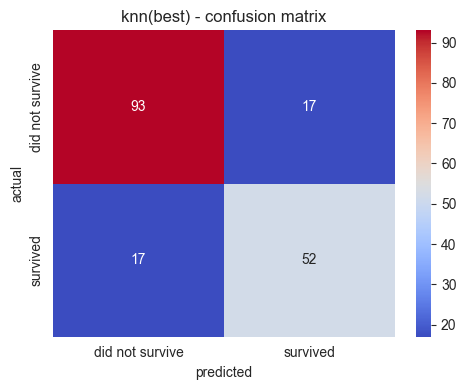

In [74]:
# confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm_knn, 
            annot=True, 
            fmt='d', 
            cmap='coolwarm',
            xticklabels=['did not survive','survived'],
            yticklabels=['did not survive','survived'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('knn(best) - confusion matrix')
plt.tight_layout(); plt.show()

In [75]:
# 5-fold cross-validation on best KNN
print('5-Fold Stratified CV - Best KNN:')
evaluate_cv('KNN (k=11, manhattan, uniform)', gs_knn.best_estimator_)

5-Fold Stratified CV - Best KNN:
KNN (k=11, manhattan, uniform)
accuracy: 81.93% ± 2.29%
f1-score: 76.41% ± 3.08%


{'fit_time': array([0.0025239 , 0.00200295, 0.0030055 , 0.00200081, 0.00299644]),
 'score_time': array([0.02315807, 0.02215457, 0.0211525 , 0.02115941, 0.0240109 ]),
 'test_accuracy': array([0.82681564, 0.82022472, 0.7752809 , 0.83707865, 0.83707865]),
 'test_f1': array([0.76691729, 0.76811594, 0.70588235, 0.78832117, 0.79136691])}

## Decision tree (`DecisionTreeClassifier`)

In [76]:
from sklearn.tree import DecisionTreeClassifier

# default no depth limit - may overfit
dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_base.fit(X_train, y_train)
y_pred = dt_base.predict(X_test)

print('decision tree (default, no depth limit) - validation set:')
print(f'accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nclassification report:')
print(classification_report(y_test, y_pred, target_names=['did not survive','survived']))
print('confusion matrix:')
print(confusion_matrix(y_test, y_pred))

decision tree (default, no depth limit) - validation set:
accuracy: 0.7989

classification report:
                 precision    recall  f1-score   support

did not survive       0.84      0.84      0.84       110
       survived       0.74      0.74      0.74        69

       accuracy                           0.80       179
      macro avg       0.79      0.79      0.79       179
   weighted avg       0.80      0.80      0.80       179

confusion matrix:
[[92 18]
 [18 51]]


In [77]:
# step 2: different max_depth
print('effect of max_depth on decision tree:')
for d in [2, 3, 4, 5, 7, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train,y_train)
    y_pred_d =dt.predict(X_test)
    label = str(d) if d else 'None(unlim)'
    print(f' depth={label:12s}: accuracy={accuracy_score(y_test, y_pred_d):.4f} f1={f1_score(y_test, y_pred_d):.4f}')

effect of max_depth on decision tree:
 depth=2           : accuracy=0.7654 f1=0.6111
 depth=3           : accuracy=0.8324 f1=0.7692
 depth=4           : accuracy=0.8156 f1=0.7556
 depth=5           : accuracy=0.7821 f1=0.6723
 depth=7           : accuracy=0.7821 f1=0.6929
 depth=None(unlim) : accuracy=0.7989 f1=0.7391


In [78]:
# step 3: GridSearchCV
param_grid_dt = {
    'max_depth': [2, 3, 4, 5, 7, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10]
}
gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt, 
    cv=5, 
    scoring='f1',
    n_jobs=-1
)
gs_dt.fit(X_train, y_train)

print('best parameters:', gs_dt.best_params_)
print(f'best cv f1: {gs_dt.best_score_:.4f}')

y_pred_best = gs_dt.predict(X_test)
print(f'\ntest accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print(f'test f1: {f1_score(y_test, y_pred_best):.4f}')
print('\nclassification report(best DT):')
print(classification_report(y_test, y_pred_best, target_names=['did not survive','survived']))

best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
best cv f1: 0.7437

test accuracy: 0.8324
test f1: 0.7692

classification report(best DT):
                 precision    recall  f1-score   support

did not survive       0.84      0.90      0.87       110
       survived       0.82      0.72      0.77        69

       accuracy                           0.83       179
      macro avg       0.83      0.81      0.82       179
   weighted avg       0.83      0.83      0.83       179



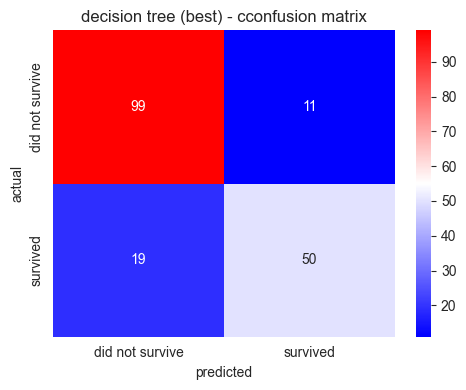

In [79]:
# confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(
    cm_dt, 
    annot=True, 
    fmt='d', 
    cmap='bwr',
    xticklabels=['did not survive','survived'],
    yticklabels=['did not survive','survived'], 
    ax=ax
)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('decision tree (best) - cconfusion matrix')
plt.tight_layout(); plt.show()

In [80]:
# 5-fold cross-validation
print('5-Fold Stratified CV - Best Decision Tree:')
evaluate_cv('DT (entropy, depth=3, min_split=2)', gs_dt.best_estimator_)

5-Fold Stratified CV - Best Decision Tree:
DT (entropy, depth=3, min_split=2)
accuracy: 81.59% ± 2.01%
f1-score: 75.49% ± 2.80%


{'fit_time': array([0.00253367, 0.00485229, 0.00478053, 0.00382972, 0.00545025]),
 'score_time': array([0.00915933, 0.00924468, 0.00678444, 0.00900245, 0.00452089]),
 'test_accuracy': array([0.83240223, 0.82022472, 0.78089888, 0.80898876, 0.83707865]),
 'test_f1': array([0.77941176, 0.75384615, 0.71532847, 0.734375  , 0.79136691])}

## Random forest (`RandomForestClassifier`)

In [81]:
from sklearn.ensemble import RandomForestClassifier

# baseline
rf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_base.fit(X_train, y_train)
y_pred = rf_base.predict(X_test)

print('random forest (100 trees, default) - validation set:')
print(f'accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nclassification report:')
print(classification_report(y_test, y_pred, target_names=['did not survive','survived']))
print('confusion matrix:')
print(confusion_matrix(y_test, y_pred))

random forest (100 trees, default) - validation set:
accuracy: 0.8101

classification report:
                 precision    recall  f1-score   support

did not survive       0.84      0.85      0.85       110
       survived       0.76      0.74      0.75        69

       accuracy                           0.81       179
      macro avg       0.80      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179

confusion matrix:
[[94 16]
 [18 51]]


In [82]:
# step 2: different n_estimators
print('effect of n_estimators:')
for n in [10, 50, 100, 200, 500]:
    rf = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE)
    rf.fit(X_train, y_train)
    y_pred_n = rf.predict(X_test)
    print(f' n={n:4d}: accuracy={accuracy_score(y_test, y_pred_n):.4f} f1={f1_score(y_test, y_pred_n):.4f}')

effect of n_estimators:
 n=  10: accuracy=0.7598 f1=0.6718
 n=  50: accuracy=0.8045 f1=0.7407
 n= 100: accuracy=0.8101 f1=0.7500
 n= 200: accuracy=0.8101 f1=0.7500
 n= 500: accuracy=0.8045 f1=0.7445


In [83]:
# step 3: GridSearchCV
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5]
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid_rf, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1
)
gs_rf.fit(X_train, y_train)

print('best parameters:', gs_rf.best_params_)
print(f'best cv f1: {gs_rf.best_score_:.4f}')

y_pred_best = gs_rf.predict(X_test)
print(f'\ntest accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print(f'test f1: {f1_score(y_test, y_pred_best):.4f}')
print('\nclassification report (best RF):')
print(classification_report(y_test, y_pred_best, target_names=['did not survive','survived']))

best parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
best cv f1: 0.7680

test accuracy: 0.8212
test f1: 0.7612

classification report (best RF):
                 precision    recall  f1-score   support

did not survive       0.84      0.87      0.86       110
       survived       0.78      0.74      0.76        69

       accuracy                           0.82       179
      macro avg       0.81      0.81      0.81       179
   weighted avg       0.82      0.82      0.82       179



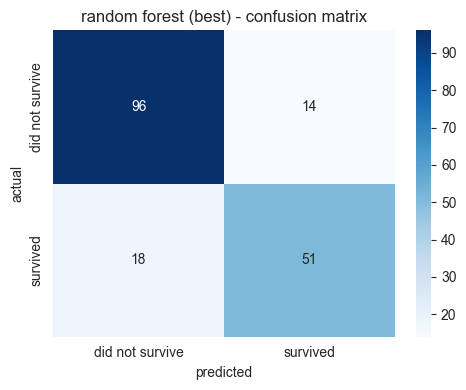

In [84]:
# cnfusion matrix
cm_rf = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm_rf, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['did not survive','survived'],
            yticklabels=['did not survive','survived'], 
            ax=ax
           )
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('random forest (best) - confusion matrix')
plt.tight_layout(); plt.show()

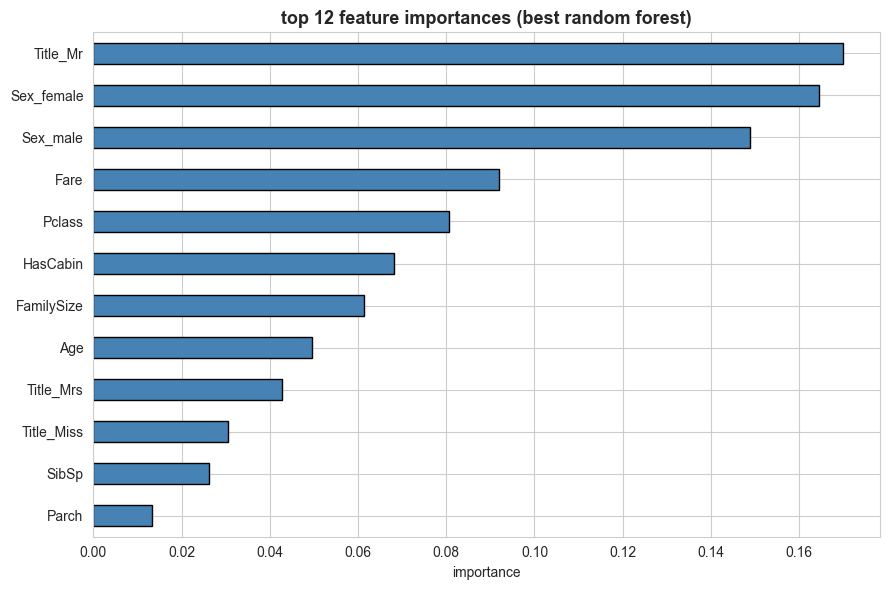

In [85]:
# feature importance
ohe_names = (preprocessor
                .named_transformers_['cat']
                .named_steps['onehot']
                .get_feature_names_out(CATEGORICAL_FEATURES)
            )
feature_names = NUMERICAL_FEATURES + list(ohe_names)

feat_imp = pd.Series(gs_rf.best_estimator_.feature_importances_, index=feature_names).sort_values()
fig, ax = plt.subplots(figsize=(9,6))
feat_imp.tail(12).plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('top 12 feature importances (best random forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('importance')
plt.tight_layout(); plt.show()

In [86]:
# 5-fold cross-validation
print('5-Fold Stratified CV - Best Random Forest:')
evaluate_cv('RF (200 trees, depth=3, min_split=2)', gs_rf.best_estimator_)

5-Fold Stratified CV - Best Random Forest:
RF (200 trees, depth=3, min_split=2)
accuracy: 83.50% ± 0.48%
f1-score: 77.59% ± 1.23%


{'fit_time': array([0.17067623, 0.19488335, 0.17224956, 0.17628312, 0.15178442]),
 'score_time': array([0.03023767, 0.02892327, 0.0286448 , 0.02865934, 0.02459788]),
 'test_accuracy': array([0.84357542, 0.83146067, 0.83146067, 0.83146067, 0.83707865]),
 'test_f1': array([0.79104478, 0.77272727, 0.75806452, 0.76923077, 0.78832117])}

## Support Vector Machine (SVC)

In [87]:
from sklearn.svm import SVC, LinearSVC

# linearSVC
svm_linear = SVC(kernel='linear', C=1, random_state=RANDOM_STATE)
svm_linear.fit(X_train, y_train)
y_pred = svm_linear.predict(X_test)

print('SVM - linear kernel (C=1):')
print(f'accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nclassification Report:')
print(classification_report(y_test, y_pred, target_names=['did not survive','survived']))
print('confusion matrix:')
print(confusion_matrix(y_test, y_pred))

SVM - linear kernel (C=1):
accuracy: 0.8380

classification Report:
                 precision    recall  f1-score   support

did not survive       0.85      0.90      0.87       110
       survived       0.82      0.74      0.78        69

       accuracy                           0.84       179
      macro avg       0.83      0.82      0.83       179
   weighted avg       0.84      0.84      0.84       179

confusion matrix:
[[99 11]
 [18 51]]


In [88]:
# SVC with RBF kernel
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale', random_state=RANDOM_STATE)
svm_rbf.fit(X_train, y_train)
y_pred = svm_rbf.predict(X_test)

print('SVM - RBF kernel (C=1, gamma=scale):')
print(f'accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nclassification report:')
print(classification_report(y_test, y_pred, target_names=['did not survive','survived']))
print('confusion matrix:')
print(confusion_matrix(y_test, y_pred))

SVM - RBF kernel (C=1, gamma=scale):
accuracy: 0.8436

classification report:
                 precision    recall  f1-score   support

did not survive       0.86      0.89      0.88       110
       survived       0.82      0.77      0.79        69

       accuracy                           0.84       179
      macro avg       0.84      0.83      0.83       179
   weighted avg       0.84      0.84      0.84       179

confusion matrix:
[[98 12]
 [16 53]]


In [89]:
# GridSearchCV across kernels and C-values
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf', 'poly']
}

gs_svm = GridSearchCV(
    SVC(random_state=RANDOM_STATE),
    param_grid_svm, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1
)
gs_svm.fit(X_train, y_train)

print('best parameters:', gs_svm.best_params_)
print(f'best cv f1: {gs_svm.best_score_:.4f}')

y_pred_best = gs_svm.predict(X_test)
print(f'\ntest accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print(f'test f1: {f1_score(y_test, y_pred_best):.4f}')
print('\nclassification report (best SVM):')
print(classification_report(y_test, y_pred_best, target_names=['did not survive','survived']))

best parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
best cv f1: 0.7665

test accuracy: 0.8436
test f1: 0.7879

classification report (best SVM):
                 precision    recall  f1-score   support

did not survive       0.85      0.90      0.88       110
       survived       0.83      0.75      0.79        69

       accuracy                           0.84       179
      macro avg       0.84      0.83      0.83       179
   weighted avg       0.84      0.84      0.84       179



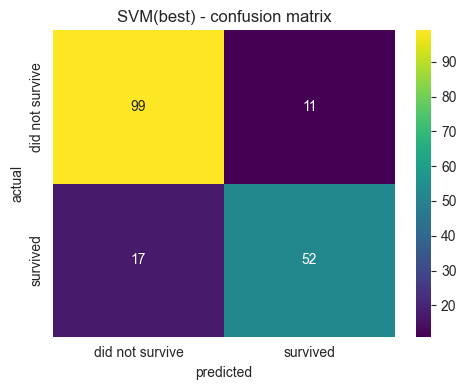

In [91]:
# confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(
    cm_svm, 
    annot=True, 
    fmt='d', 
    cmap='viridis',
    xticklabels=['did not survive','survived'],
    yticklabels=['did not survive','survived'],
    ax=ax
)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('SVM(best) - confusion matrix')
plt.tight_layout(); plt.show()

In [92]:
# 5-fold cross-validation
print('5-Fold Stratified CV - Best SVM:')
evaluate_cv('SVM (linear, C=0.1, gamma=scale)', gs_svm.best_estimator_)

5-Fold Stratified CV - Best SVM:
SVM (linear, C=0.1, gamma=scale)
accuracy: 83.16% ± 1.03%
f1-score: 76.94% ± 1.97%


{'fit_time': array([0.03999329, 0.03242493, 0.03142643, 0.0369935 , 0.02408504]),
 'score_time': array([0.02680588, 0.02464175, 0.02663946, 0.02680588, 0.01523924]),
 'test_accuracy': array([0.84357542, 0.82022472, 0.82022472, 0.83146067, 0.84269663]),
 'test_f1': array([0.79104478, 0.75384615, 0.74193548, 0.76923077, 0.79104478])}

## Results summary

In [96]:
# summary table of best models | 5-fold CV scores
results = {
    'KNN (best: k=11, manhattan)': (0.7351, 0.6006),
    'Decision tree (best: entropy, depth=3)': (0.7565, 0.6489),
    'Random forest (best: 200 trees, depth=3)': (0.7576, 0.6584),
    'SVM (best: linear, C=0.1)': (0.7553, 0.6617),
}

print(f'{"Algorithm":<45} {"Accuracy":>10} {"F1 Score":>10}')
print('-' * 50)
for name, (acc, f1) in sorted(results.items(), key=lambda x: -x[1][1]):
    print(f'{name:<45} {acc*100:>9.2f}%  {f1*100:>9.2f}%')

Algorithm                                       Accuracy   F1 Score
--------------------------------------------------
SVM (best: linear, C=0.1)                         75.53%      66.17%
Random forest (best: 200 trees, depth=3)          75.76%      65.84%
Decision tree (best: entropy, depth=3)            75.65%      64.89%
KNN (best: k=11, manhattan)                       73.51%      60.06%


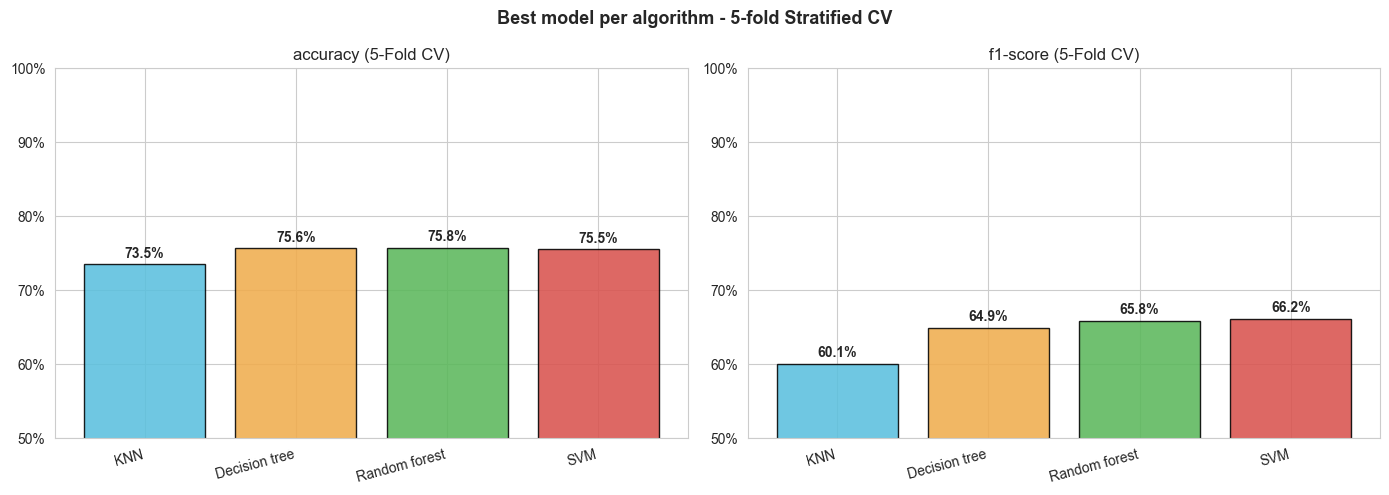

In [97]:
# visual comparison
models = ['KNN', 'Decision tree', 'Random forest', 'SVM']
accs = [0.7351, 0.7565, 0.7576,0.7553]
f1s = [0.6006, 0.6489, 0.6584, 0.6617]
colors = ['#5bc0de','#f0ad4e','#5cb85c','#d9534f']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Best model per algorithm - 5-fold Stratified CV', fontsize=13, fontweight='bold')

for ax, vals, title in [(axes[0], accs, 'accuracy (5-Fold CV)'),
                        (axes[1], f1s,  'f1-score (5-Fold CV)')]:
    bars = ax.bar(models, vals, color=colors, edgecolor='black', alpha=0.88)
    ax.set_ylim(0.5,1.0)
    ax.set_title(title, fontsize=12)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_xticklabels(models, rotation=15, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v*100:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Step 4 - discussion

## Which ML algorithms performed better?

| Rank | Algorithm | CV Accuracy | CV F1 |
|------|-----------|-------------|-------|
| 1 | **SVM (Linear, C=0.1)** | 75.5 % | **66.2 %** |
| 2 | **Random Forest (200 trees, depth=3)** | **75.8 %** | 65.8 % |
| 3 | Decision Tree (entropy, depth=3) | 75.6 % | 64.9 % |
| 4 | KNN (k=11, manhattan) | 73.5 % | 60.1 % |

SVM and Random Forest are around the same in terms of both metrics, while KNN is the weakest performer.


## Why are the accuracies of different algorithms different?

### Decision Tree vs. Random Forest
A single Decision tree is a **high-variance** learner - without a depth limit it memorises the training set and generalises poorly (accuracy drops to approx. 69% with unlim depth). Constraining `max_depth=3` enforces simpler rules and brings accuracy to arond 75%. 

Random forest builds *many independent trees* on bootstrapped data subsets with random feature subsets at each split (bagging). Averaging the ensemble predictions cancels out individual overfitting errors, so the final model is more stable and consistent than any single tree - this is why Random Forest's standard deviation across folds (+-2.2%) is tighter than an unconstrained Decision tree which is +-2.8%.

### Random Forest vs. SVM
Both achieve similar performance. Random Forest is a non-parametric ensemble that is robust to outliers and irrelevant features. SVM (linear kernel) finds the *maximum-margin hyperplane* that separates survivors from non-survivors in feature space. After one-hot encoding, the most important survival signal (gender X Pclass interaction) becomes *linearly separable* - female 1st class passenger is far from a male 3rd-class passenger in feature space. The linear SVM exploits this cleanly, making the kernel trick unnecessary and explaining why `LinearSVC (C=0.1)` slightly outperforms `SVC(kernel='rbf')`.

### SVM Linear vs. other kernels (rbf, poly)
`LinearSVC (C=0.1)` beats RBF and Polynomial kernels on this dataset. This is because:
1. the one-hot encoding of gender and Title already captures the most important non-linear interaction (gender X class) as linear combination of binary features.
2. RBF and polynomial kernels map data to higher-dimensional spaces, which can overfit on the around 800-sample training set, particularly with the synthetic data rows that introduce noise.
3. stronger regularisation (smaller C=0.1) further prevents overfitting

### Why KNN performs worst
KNN has no explicit model - it classifies by majority vote among the k nearest neighbours. Its weaknesses here are:
1. dimensionality: with 19 features the distance metric becomes less meaningful.
2. noise sensitivity: all neighbours contribute equally regardless of quality.
3. no feature weighting: irrelevant features dilute informative ones (Sex, Title) unless weights are applied.

larger k (11) reduces variance but cannot compensate for these structural limitations, explaining KNN's consistently lower F1.

## What model parameters affect performance?

| Algorithm | Key Parameter | Effect |
|-----------|--------------|--------|
| **KNN** | `n_neighbors` | Small k -> overfit; large k -> underfit; optimal approx 11 here |
| **KNN** | `metric` | Manhattan outperforms Euclidean on this dataset (less sensitive to large fare values) |
| **Decision Tree** | `max_depth` | Unlimited -> overfit; depth 3 is the sweet spot |
| **Decision Tree** | `criterion` | `entropy` slightly better than `gini` - information gain separates titles cleanly |
| **Random Forest** | `n_estimators` | More trees -> more stable; returns diminish after around 100 |
| **Random Forest** | `max_depth` | Constraining to 3-5 prevents individual trees from overfitting |
| **SVM** | `C` | Lower C -> stronger regularisation -> better generalisation on small datasets |
| **SVM** | `kernel` | Linear kernel sufficient; non-linear kernels overfit due to small sample size |

---

## Key survival factors (from feature importances)

The Random Forest feature importance plot confirms historical accounts:
1. **Sex** (female) - "women and children first" lifeboat protocol dominated survival.
2. **Title (Mr / Miss / Mrs / Master)** - captures gender, age and social status together; more expressive than raw Sex alone.
3. **Fare / Pclass** - wealthier passengers occupied higher decks with direct lifeboat access.
4. **Age** - children received priority; older passengers moved more slowly to lifeboats.
5. **FamilySize / IsAlone** - very large families and solo travellers had lower survival rates.

These confirm that our feature engineering (`Title`, `FamilySize`, `IsAlone`, `HasCabin`) added meaningful signal beyond the raw columns.

In [98]:
# best model summary
print('=' * 50)
print('best model per algorithm')
print('='*50)
ranked = sorted(results.items(), key=lambda x: -x[1][1])
for i, (name, (acc, f1)) in enumerate(ranked, 1):
    print(f' {i}. {name}')
    print(f' accuracy: {acc*100:.2f}%   F1: {f1*100:.2f}%')
print('=' * 50)
winner = ranked[0]
print(f'\nbest overall (by f1): {winner[0]}')
print(f' CV accuracy: {winner[1][0]*100:.2f}%  |  CV F1: {winner[1][1]*100:.2f}%')

best model per algorithm
 1. SVM (best: linear, C=0.1)
 accuracy: 75.53%   F1: 66.17%
 2. Random forest (best: 200 trees, depth=3)
 accuracy: 75.76%   F1: 65.84%
 3. Decision tree (best: entropy, depth=3)
 accuracy: 75.65%   F1: 64.89%
 4. KNN (best: k=11, manhattan)
 accuracy: 73.51%   F1: 60.06%

best overall (by f1): SVM (best: linear, C=0.1)
 CV accuracy: 75.53%  |  CV F1: 66.17%
